### Imports

In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, f1_score, precision_score
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, recall_score

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cpu") #torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


### CSV Columns

These are the universal names for columns we have in the CSV file so that if the CSV file has a different name for a column we don't have to change it

In [4]:
# universal names for each column in the csv, added so that if the names are different we just have to change it here
# change the right values to what they are called in the csv file
CSV_COLUMNS = {
    "gene_name": "gene_name",
    "log2_fold_change": "log2FoldChange",
    "pvalue": "pvalue",
    "log_pvalue": "log_pvalue",
    "seq_length": "Sequence_Length",
    "first3": "First_3",
    "last3": "Last_3",
    "gc_pct": "GC_pct",
    "at_pct": "AT_pct",
}

### One Hot Encoding

For our first 3 and last 3 bases data, we want the neural network to take into account the actual sequence of each base, not the simple 3 letter string. We do this using one hot encoding, and so this function returns that data formatted properly.

In [5]:
# the purpose of this is that so the position of each base in the first/last 3 codons is taken into account
# this is better as it doesn't just take the 3 letter string as an input
BASES = ["A", "C", "G", "T"]

def one_hot_positions(series, prefix):
    """One-hot encode a column of 3-letter strings into 12 binary columns
    (3 positions x 4 bases)."""
    out = pd.DataFrame(index=series.index)
    for pos in range(3):
        for base in BASES:
            col_name = f"{prefix}_pos{pos+1}_{base}"
            out[col_name] = (series.str.upper().str[pos] == base).astype(int)
    return out

### Classes

- GeneDataset formats data in a way PyTorch understands.
- GeneMLP is the structure of our neural network.
- TrainedModel stores our trained neural network to use/test for later.

In [6]:
# pytorch dataset to handle data in correct format
class GeneDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)
    
    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# neural network model to predict numerical data
class GeneMLP(nn.Module):
    # input_dim = # of features in input matrix X
    # hidden1 = number of neurons hidden in the first layer
    #   - produces a number of outputs containing initial patterns
    # hidden2 = number of neurons hidden in the second layer
    #   - takes the outputs from the first layer and compresses it to smaller dimensions
    #   - helps distill the more important features
    # dropout = the % chance of a neuron "turning off" during training. this prevents:
    #   - the network becoming overly dependent on certain features (memorization)
    def __init__(self, input_dim, hidden1=32, hidden2=16, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, 1),
        )

    # pass input matrix X through neural network
    def forward(self, x):
        return self.net(x)

class TrainedModel:
    def __init__(self, fold_models, history, output, X_arr, y_arr):
        self.fold_models = fold_models
        self.history = history
        self.output_type = output
        self.X_arr = X_arr
        self.y_arr = y_arr

### Train One Fold

This function takes one piece of the data, builds a fresh neural network from scratch, and iteratively trains its weights to minimize prediction errors. It simultaneously monitors a separate validation set to prevent overfitting, automatically stopping the process the moment the model stops improving and returning the best version of the network.

In [7]:
def train_one_fold_numeric(X_train, y_train, X_val, y_val, input_dim,
                           epochs=300, patience=20, lr=1e-3, weight_decay=1e-3,
                           batch_size=32, verbose=False):
    train_loader = DataLoader(GeneDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(GeneDataset(X_val, y_val), batch_size=batch_size, shuffle=False)

    model = GeneMLP(input_dim=input_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()

    best_val_loss = float("inf")
    best_state = None
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(epochs):
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())
                
        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:  # <--- Correctly iterating over the validation set
                xb, yb = xb.to(device), yb.to(device)
                val_losses.append(loss_fn(model(xb), yb).item())
        
        train_loss = np.mean(train_losses)
        val_loss = np.mean(val_losses)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if verbose and epoch % 20 == 0:
            print(f"  epoch {epoch:3d} train={train_loss:.4f}  val={val_loss:.4f}")
        
        # early stopping
        if val_loss < best_val_loss - 1e-5:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                if verbose:
                    print(f"  early stopping at epoch {epoch}")
                break
    
    model.load_state_dict(best_state)
    return model, history

### Train Model

This function combines everything and returns a TrainedModel object. 

Parameters:
- input_file: the name of the file you want to train data on
- target_key: the name of the key in CSV_COLUMNS for the target data you want to predict
- data_pct: the percentage of data you want to train the model on

In [8]:
def train_model_numeric(input_file, target_key, data_pct=None, epochs=3000):
    print(f"Training neural network on file {input_file} to predict '{target_key}'")

    COLUMNS = CSV_COLUMNS.copy()
    
    # check if target exists in our dictionary
    if target_key not in COLUMNS:
        raise ValueError(f"Target '{target_key}' not found in CSV_COLUMNS dictionary.")
    
    target_col_name = COLUMNS[target_key]
    

    # extract data with pandas, not including gene name
    df_full = pd.read_csv(input_file).drop(columns=[COLUMNS["gene_name"]])
    print(f"\nExtracted data from {input_file}:")
    
    # train on half the rows by default
    if data_pct is None:
        data_pct = 0.5
    
    # randomize portion of data
    rng = np.random.default_rng(SEED)
    shuffled_idx = rng.permutation(len(df_full))
    num_training_rows = int(len(df_full) * data_pct)
    use_idx = shuffled_idx[:num_training_rows]
    unused_idx = shuffled_idx[num_training_rows:]

    df = df_full.iloc[use_idx].reset_index(drop=True)
    df_unused = df_full.iloc[unused_idx].reset_index(drop=True)
    print(f"Separated a random sample of {len(df)}/{len(df_full)} rows of data for training")

    # get first/last 3 one hot encodings
    first3_oh = one_hot_positions(df[COLUMNS["first3"]], "first3")
    last3_oh = one_hot_positions(df[COLUMNS["last3"]], "last3")


    # keys that should never be treated as standard numeric inputs
    # we remove pvalue and at_pct, because log pvalue and gc_pct are the same information, just represented differently
    exclude_keys = ["gene_name", "first3", "last3", "pvalue", "at_pct", "log_pvalue"]
    numeric_cols = []
    
    # validate input keys
    for key, col_name in COLUMNS.items():
        # skip text identifiers and one-hot encoded columns
        if key in exclude_keys:
            continue
            
        # skip the target variable so the model can't cheat
        if key == target_key:
            continue
            
            
        # if it passes all checks, it's a valid numeric feature
        numeric_cols.append(col_name)
        
    print(f"Using the following numeric features: {numeric_cols}")

    # join encodings with numeric columns
    X = pd.concat([df[numeric_cols].reset_index(drop=True), first3_oh.reset_index(drop=True), last3_oh.reset_index(drop=True)], axis=1)

    # dynamically set target variable
    y = df[target_col_name].values.astype(np.float32)

    print("Feature matrix shape:", X.shape)

    X_arr = X.values.astype(np.float32)
    y_arr = y

    # begin training model with 5 folds
    N_FOLDS = 5
    kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

    fold_results = []
    fold_models = []

    print("\nTraining model...")
    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_arr)):
        print(f"--- Fold {fold_idx + 1}/{N_FOLDS} ---")

        X_train_raw, X_val_raw = X_arr[train_idx], X_arr[val_idx]
        y_train, y_val = y_arr[train_idx], y_arr[val_idx]

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train_raw)
        X_val = scaler.transform(X_val_raw)

        # Passes dynamic input_dim based on the number of features kept
        model, history = train_one_fold_numeric(
            X_train, y_train, X_val, y_val,
            input_dim=X_train.shape[1], verbose=True, epochs=epochs
        )

        model.eval()
        with torch.no_grad():
            val_preds = model(torch.tensor(X_val, dtype=torch.float32).to(device)).cpu().numpy().flatten()
        
        mae = mean_absolute_error(y_val, val_preds)
        rmse = mean_squared_error(y_val, val_preds) ** 0.5
        r2 = r2_score(y_val, val_preds)

        print(f"  Fold {fold_idx+1}  MAE={mae:.4f}  RMSE={rmse:.4f}  R2={r2:.4f}")
        fold_results.append({"fold": fold_idx + 1, "mae": mae, "rmse": rmse, "r2": r2})
        fold_models.append((model, scaler, val_idx))

    results_df = pd.DataFrame(fold_results)
    print("\n=== Cross-validation summary ===")
    print(results_df.to_string(index=False))
    print(f"\nMean MAE:  {results_df['mae'].mean():.4f}  +/- {results_df['mae'].std():.4f}")
    print(f"Mean RMSE: {results_df['rmse'].mean():.4f}  +/- {results_df['rmse'].std():.4f}")
    print(f"Mean R2:   {results_df['r2'].mean():.4f}  +/- {results_df['r2'].std():.4f}")

    plt.figure(figsize=(7, 4))
    plt.plot(history["train_loss"], label="train loss")
    plt.plot(history["val_loss"],   label="val loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE loss")
    plt.title("Training curve — last fold")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    
    return TrainedModel(fold_models, history, target_col_name, X_arr, y_arr)

### Test Model

This function calculates baseline metrics and compares them to the metrics of our model, generating visualizers in the process.

In [9]:
# test and analyze model
def test_model(trained_model):
    all_true = []
    all_preds = []

    fold_models = trained_model.fold_models
    X_arr = trained_model.X_arr
    y_arr = trained_model.y_arr

    for model, scaler, val_idx in fold_models:
        X_val_raw = X_arr[val_idx]
        X_val_scaled = scaler.transform(X_val_raw)
        
        model.eval()
        with torch.no_grad():
            X_tensor = torch.tensor(X_val_scaled, dtype=torch.float32).to(device)
            preds = model(X_tensor).cpu().numpy().flatten()
            
        all_true.extend(y_arr[val_idx])
        all_preds.extend(preds)

    all_true = np.array(all_true)
    all_preds = np.array(all_preds)
    
    # --- Calculate Residuals ---
    residuals = all_true - all_preds

    # Calculate Model Metrics
    overall_mae = mean_absolute_error(all_true, all_preds)
    overall_rmse = mean_squared_error(all_true, all_preds) ** 0.5
    overall_r2 = r2_score(all_true, all_preds)

    # --- Calculate Naive Baseline Metrics (Predicting the global mean) ---
    baseline_preds = np.full(all_true.shape, np.mean(y_arr))
    baseline_mae = mean_absolute_error(all_true, baseline_preds)
    baseline_r2 = r2_score(all_true, baseline_preds)

    print(f"=== Evaluation Dashboard ({trained_model.output_type}) ===")
    print(f"Model Metrics    -> Mean Absolute Error: {overall_mae:.4f} | Root Mean Squared Error: {overall_rmse:.4f} | R2: {overall_r2:.4f}")
    print(f"Baseline Metrics -> Mean Absolute Error: {baseline_mae:.4f} | R2: {baseline_r2:.4f}")
    if overall_r2 < baseline_r2:
        print("⚠️ ALERT: Your Neural Network is currently performing worse than predicting the mean.")
    else:
        print("✅ Neural Network performing better than predicting mean")
    print("=" * 45 + "\n")

    # --- Expanded 3-Plot Visualization ---
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Plot 1: Predicted vs Actual
    lims = [min(all_true.min(), all_preds.min()), max(all_true.max(), all_preds.max())]
    axes[0].scatter(all_true, all_preds, alpha=0.5, color="teal")
    axes[0].plot(lims, lims, "r--", label="Perfect Prediction")
    axes[0].set_xlabel(f"Actual {trained_model.output_type}")
    axes[0].set_ylabel(f"Predicted {trained_model.output_type}")
    axes[0].set_title("Predicted vs Actual")
    axes[0].legend()

    # Plot 2: Residuals vs Predicted (Look for systematic patterns)
    axes[1].scatter(all_preds, residuals, alpha=0.5, color="purple")
    axes[1].axhline(y=0, color="r", linestyle="--")
    axes[1].set_xlabel("Predicted Values")
    axes[1].set_ylabel("Residuals (Actual - Predicted)")
    axes[1].set_title("Residuals vs. Predicted")

    # Plot 3: Distribution of Errors (Should ideally be normal/bell-shaped)
    axes[2].hist(residuals, bins=20, color="dimgray", edgecolor="black", alpha=0.7)
    axes[2].axvline(x=0, color="r", linestyle="--")
    axes[2].set_xlabel("Prediction Error Magnitude")
    axes[2].set_ylabel("Count of Genes")
    axes[2].set_title("Distribution of Errors")

    plt.tight_layout()
    plt.show()
    
    return {"mae": overall_mae, "rmse": overall_rmse, "r2": overall_r2}

In [10]:
# test log2 fold change
log2fc_model_50 = train_model_numeric("PAO1.csv", "log2_fold_change", .5, epochs=300)
test_model(log2fc_model_50)

Training neural network on file PAO1.csv to predict 'log2_fold_change'


FileNotFoundError: [Errno 2] No such file or directory: 'PAO1.csv'

In [ ]:
# test pval
pvalue_model_50 = train_model_numeric("PAO1.csv", "log_pvalue", .5)
test_model(pvalue_model_50)

In [ ]:
gc_model_50 = train_model_numeric("PAO1.csv", "gc_pct", .5, epochs=5000)
test_model(gc_model_50)

In [ ]:
def train_one_fold_classification(X_train, y_train, X_val, y_val, input_dim,
                                  epochs=300, patience=20, lr=1e-3, weight_decay=1e-3,
                                  batch_size=32, verbose=False):
    """
    Trains a single fold of a binary classifier that distinguishes
    UP-regulated genes (y=1, log2FC >= 1) from DOWN-regulated genes
    (y=0, log2FC <= -1). Assumes X_train/X_val/y_train/y_val already
    only contain up/down regulated genes (filtering happens upstream
    in train_model_classification).
    """
    train_loader = DataLoader(GeneDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(GeneDataset(X_val, y_val), batch_size=batch_size, shuffle=False)

    model = GeneMLP(input_dim=input_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    # 1. Calculate how many times more Down-regulated (0) genes there are than Up-regulated (1)
    num_down = (y_train == 0).sum()
    num_up = (y_train == 1).sum()
    
    # Avoid division by zero just in case
    up_weight_ratio = float(num_down) / max(float(num_up), 1.0)
    
    # 2. Convert to a tensor and send to the active device
    pos_weight_tensor = torch.tensor([up_weight_ratio], dtype=torch.float32).to(device)

    # 3. Pass it to the loss function
    # Binary classification -> weighted BCEWithLogitsLoss
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)

    best_val_loss = float("inf")
    best_state = None
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(epochs):
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()

            preds = model(xb).flatten()
            loss = loss_fn(preds, yb.flatten())

            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb).flatten()
                val_losses.append(loss_fn(preds, yb.flatten()).item())

        train_loss = np.mean(train_losses)
        val_loss = np.mean(val_losses)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if verbose and epoch % 20 == 0:
            print(f"  epoch {epoch:3d} train={train_loss:.4f}  val={val_loss:.4f}")

        if val_loss < best_val_loss - 1e-5:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                if verbose:
                    print(f"  early stopping at epoch {epoch}")
                break

    if best_state is None:
        best_state = model.state_dict()

    model.load_state_dict(best_state)
    return model, history


def train_model_classification(input_file, metric, data_pct=None, epochs=3000):
    metrics = ["first3", "last3", "gc_pct"]
    if metric not in metrics:
        print(f"Error: {metric} not a valid metric ({metrics})")
        return None

    print(f"Training neural network on file {input_file} to predict UP vs DOWN "
          f"regulation (log2FC >= 1 vs log2FC <= -1) using ONLY {metric}")

    COLUMNS = CSV_COLUMNS.copy()
    target_col_name = "log2FoldChange"

    # extract data with pandas, not including gene name
    df_full = pd.read_csv(input_file).drop(columns=[COLUMNS["gene_name"]])
    print(f"\nExtracted data from {input_file}:")

    # ONLY keep up/down regulated genes: |log2FoldChange| >= 1
    df_full = df_full[(df_full[COLUMNS["log2_fold_change"]] <= -1) |
                       (df_full[COLUMNS["log2_fold_change"]] >= 1)].reset_index(drop=True)
    print(f"Filtered to {len(df_full)} up/down regulated genes (|log2FC| >= 1)")

    # train on half the rows by default
    if data_pct is None:
        data_pct = 0.5

    # randomize portion of data
    rng = np.random.default_rng(SEED)
    shuffled_idx = rng.permutation(len(df_full))
    num_training_rows = int(len(df_full) * data_pct)
    use_idx = shuffled_idx[:num_training_rows]
    unused_idx = shuffled_idx[num_training_rows:]

    df = df_full.iloc[use_idx].reset_index(drop=True)
    df_unused = df_full.iloc[unused_idx].reset_index(drop=True)
    print(f"Separated a random sample of {len(df)}/{len(df_full)} rows of data for training")

    # CONSTRUCT FEATURE MATRIX BASED ONLY ON SPECIFIED METRIC
    if metric == "first3":
        X = one_hot_positions(df[COLUMNS["first3"]], "first3").reset_index(drop=True)
    elif metric == "last3":
        X = one_hot_positions(df[COLUMNS["last3"]], "last3").reset_index(drop=True)
    elif metric == "gc_pct":
        X = df[[COLUMNS["gc_pct"]]].reset_index(drop=True)

    print(f"Feature matrix built using exclusively: {metric}")

    # TARGET: 1 = up-regulated (log2FC >= 1), 0 = down-regulated (log2FC <= -1)
    raw_target = df[target_col_name].values
    y = (raw_target >= 1).astype(np.float32)

    print("Feature matrix shape:", X.shape)
    print(f"Target class distribution: {int(y.sum())} up-regulated vs "
          f"{int(len(y) - y.sum())} down-regulated")

    X_arr = X.values.astype(np.float32)
    y_arr = y

    # begin training model with 5 folds
    N_FOLDS = 5
    kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

    fold_results = []
    fold_models = []

    print("\nTraining model...")
    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_arr)):
        print(f"--- Fold {fold_idx + 1}/{N_FOLDS} ---")

        X_train_raw, X_val_raw = X_arr[train_idx], X_arr[val_idx]
        y_train, y_val = y_arr[train_idx], y_arr[val_idx]

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train_raw)
        X_val = scaler.transform(X_val_raw)

        model, history = train_one_fold_classification(
            X_train, y_train, X_val, y_val,
            input_dim=X_train.shape[1], verbose=True, epochs=epochs
        )

        model.eval()
        with torch.no_grad():
            val_preds = model(torch.tensor(X_val, dtype=torch.float32).to(device)).cpu().numpy().flatten()

        # logits thresholded at 0.0 (equivalent to probability 0.5)
        val_pred_labels = (val_preds > 0.0).astype(np.float32)

        acc = accuracy_score(y_val, val_pred_labels)
        f1 = f1_score(y_val, val_pred_labels, zero_division=0)
        precision = precision_score(y_val, val_pred_labels, zero_division=0)

        print(f"  Fold {fold_idx+1}  Accuracy={acc:.4f}  F1-Score={f1:.4f}  Precision={precision:.4f}")
        fold_results.append({"fold": fold_idx + 1, "accuracy": acc, "f1": f1, "precision": precision})
        fold_models.append((model, scaler, val_idx))

    results_df = pd.DataFrame(fold_results)
    print("\n=== Cross-validation summary ===")
    print(results_df.to_string(index=False))
    print(f"\nMean Accuracy:  {results_df['accuracy'].mean():.4f}  +/- {results_df['accuracy'].std():.4f}")
    print(f"Mean F1-Score:  {results_df['f1'].mean():.4f}  +/- {results_df['f1'].std():.4f}")
    print(f"Mean Precision: {results_df['precision'].mean():.4f}  +/- {results_df['precision'].std():.4f}")

    plt.figure(figsize=(7, 4))
    plt.plot(history["train_loss"], label="train loss")
    plt.plot(history["val_loss"],   label="val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Binary Cross-Entropy Loss")
    plt.title(f"Training curve — last fold ({metric})")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return TrainedModel(fold_models, history, target_col_name, X_arr, y_arr)


def test_model_classification(trained_model):
    all_true = []
    all_preds_logits = []

    fold_models = trained_model.fold_models
    X_arr = trained_model.X_arr
    y_arr = trained_model.y_arr

    # Reconstruct out-of-fold predictions
    for model, scaler, val_idx in fold_models:
        X_val_raw = X_arr[val_idx]
        X_val_scaled = scaler.transform(X_val_raw)

        model.eval()
        with torch.no_grad():
            X_tensor = torch.tensor(X_val_scaled, dtype=torch.float32).to(device)
            preds = model(X_tensor).cpu().numpy().flatten()

        all_true.extend(y_arr[val_idx])
        all_preds_logits.extend(preds)

    all_true = np.array(all_true)
    all_preds_logits = np.array(all_preds_logits)

    # threshold logits at 0.0 -> binary label
    all_preds_labels = (all_preds_logits > 0.0).astype(np.float32)

    # sigmoid -> probability of being up-regulated
    all_preds_probs = 1 / (1 + np.exp(-all_preds_logits))

    overall_acc = accuracy_score(all_true, all_preds_labels)
    overall_f1 = f1_score(all_true, all_preds_labels, zero_division=0)
    overall_precision = precision_score(all_true, all_preds_labels, zero_division=0)

    # naive baseline: always predict the majority direction (up or down)
    majority_class = 1.0 if np.mean(y_arr) > 0.5 else 0.0
    baseline_preds = np.full(all_true.shape, majority_class)
    baseline_acc = accuracy_score(all_true, baseline_preds)

    print(f"=== Evaluation Dashboard: Predicting Up- vs Down-Regulation ===")
    print(f"Model Metrics    -> Accuracy: {overall_acc:.4f} | F1-Score: {overall_f1:.4f} | Precision: {overall_precision:.4f}")
    print(f"Baseline Metrics -> Accuracy: {baseline_acc:.4f} (always predicting "
          f"{'up-regulated' if majority_class == 1.0 else 'down-regulated'})")

    if overall_acc < baseline_acc:
        print("⚠️ ALERT: Your Neural Network is currently performing worse than the naive majority-class baseline.")
    else:
        print("✅ Neural Network performing better than baseline accuracy")
    print("=" * 60 + "\n")

    # --- 3-panel visualization ---
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Plot 1: Confusion matrix
    cm = confusion_matrix(all_true, all_preds_labels)
    axes[0].matshow(cm, cmap="GnBu", alpha=0.8)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            axes[0].text(x=j, y=i, s=f"{cm[i, j]}", va="center", ha="center", size="xx-large", weight="bold")

    axes[0].xaxis.set_ticks_position("bottom")
    axes[0].set_xticks([0, 1])
    axes[0].set_yticks([0, 1])
    axes[0].set_xticklabels(["Down-regulated (0)", "Up-regulated (1)"])
    axes[0].set_yticklabels(["Down-regulated (0)", "Up-regulated (1)"])
    axes[0].set_xlabel("Predicted Label")
    axes[0].set_ylabel("True Label")
    axes[0].set_title("Confusion Matrix")

    # Plot 2: Distribution of predicted probabilities, split by true class
    axes[1].hist(all_preds_probs[all_true == 0], bins=15, alpha=0.6, color="crimson",
                 label="True Down-regulated (0)", edgecolor="black")
    axes[1].hist(all_preds_probs[all_true == 1], bins=15, alpha=0.6, color="teal",
                 label="True Up-regulated (1)", edgecolor="black")
    axes[1].axvline(x=0.5, color="black", linestyle="--", label="Decision Threshold")
    axes[1].set_xlabel("Predicted Probability of Up-Regulation")
    axes[1].set_ylabel("Count of Genes")
    axes[1].set_title("Distribution of Predicted Probabilities")
    axes[1].legend()

    # Plot 3: ROC curve
    fpr, tpr, _ = roc_curve(all_true, all_preds_probs)
    roc_auc = auc(fpr, tpr)
    axes[2].plot(fpr, tpr, color="dimgray", lw=2, label=f"ROC Curve (AUC = {roc_auc:.2f})")
    axes[2].plot([0, 1], [0, 1], color="r", linestyle="--", label="Random Guess")
    axes[2].set_xlabel("False Positive Rate")
    axes[2].set_ylabel("True Positive Rate")
    axes[2].set_title("ROC Curve: Up- vs Down-Regulation")
    axes[2].legend(loc="lower right")

    plt.tight_layout()
    plt.show()

    return {"accuracy": overall_acc, "f1": overall_f1, "precision": overall_precision}

In [ ]:
mod = train_model_classification(input_file="PAO1.csv", metric = "gc_pct", data_pct=.8)
test_model_classification(mod)

In [ ]:
mod = train_model_classification(input_file="PAO1.csv", metric = "first3", data_pct=.8)
test_model_classification(mod)

In [ ]:
def test_independent_file_with_dashboard(trained_model_obj, test_file, metric):
    """
    Evaluates the trained ensemble on a completely NEW test file
    using the 3-panel visualization dashboard format and the global CSV_COLUMNS.
    """
    # 1. Load and process the independent test dataset
    target_col_name = "log2FoldChange"
    df_test = pd.read_csv(test_file)
    
    # Filter to up/down regulated genes using the global CSV_COLUMNS
    df_test = df_test[(df_test[CSV_COLUMNS["log2_fold_change"]] <= -1) |
                      (df_test[CSV_COLUMNS["log2_fold_change"]] >= 1)].reset_index(drop=True)
    
    if len(df_test) == 0:
        print("Error: No data left after filtering.")
        return None
        
    # Build feature matrix matching the chosen metric channel
    if metric == "first3":
        X_test_df = one_hot_positions(df_test[CSV_COLUMNS["first3"]], "first3").reset_index(drop=True)
    elif metric == "last3":
        X_test_df = one_hot_positions(df_test[CSV_COLUMNS["last3"]], "last3").reset_index(drop=True)
    elif metric == "gc_pct":
        X_test_df = df_test[[CSV_COLUMNS["gc_pct"]]].reset_index(drop=True)
    else:
        raise ValueError(f"Unknown metric: {metric}")
        
    X_test_raw = X_test_df.values.astype(np.float32)
    all_true = (df_test[target_col_name].values >= 1).astype(np.float32)
    
    # 2. Predict using Ensemble Averaging
    all_fold_logits = []
    first_model = trained_model_obj.fold_models[0][0]
    device = next(first_model.parameters()).device
    
    for model, scaler, _ in trained_model_obj.fold_models:
        model.eval()
        X_test_scaled = scaler.transform(X_test_raw)
        X_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
        
        with torch.no_grad():
            preds = model(X_tensor).cpu().numpy().flatten()
            all_fold_logits.append(preds)
            
    # Ensemble average the logits across all folds
    mean_logits = np.mean(all_fold_logits, axis=0)
    all_preds_labels = (mean_logits > 0.0).astype(np.float32)
    all_preds_probs = 1 / (1 + np.exp(-mean_logits))
    
    # 3. Calculate Metrics
    overall_acc = accuracy_score(all_true, all_preds_labels)
    overall_f1 = f1_score(all_true, all_preds_labels, zero_division=0)
    overall_precision = precision_score(all_true, all_preds_labels, zero_division=0)
    
    # Baseline comparison (based on the new test file's distribution)
    majority_class = 1.0 if np.mean(all_true) > 0.5 else 0.0
    baseline_preds = np.full(all_true.shape, majority_class)
    baseline_acc = accuracy_score(all_true, baseline_preds)
    
    print(f"=== Independent Test Dashboard: Predicting Up- vs Down-Regulation ===")
    print(f"Model Metrics    -> Accuracy: {overall_acc:.4f} | F1-Score: {overall_f1:.4f} | Precision: {overall_precision:.4f}")
    print(f"Baseline Metrics -> Accuracy: {baseline_acc:.4f} (always predicting "
          f"{'up-regulated' if majority_class == 1.0 else 'down-regulated'})")
    
    if overall_acc < baseline_acc:
        print("⚠️ ALERT: Your Neural Network is currently performing worse than the naive majority-class baseline on this file.")
    else:
        print("✅ Neural Network performing better than baseline accuracy")
    print("=" * 60 + "\n")
    
    # 4. 3-panel visualization dashboard
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Panel 1: Confusion matrix
    cm = confusion_matrix(all_true, all_preds_labels)
    axes[0].matshow(cm, cmap="GnBu", alpha=0.8)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            axes[0].text(x=j, y=i, s=f"{cm[i, j]}", va="center", ha="center", size="xx-large", weight="bold")
            
    axes[0].xaxis.set_ticks_position("bottom")
    axes[0].set_xticks([0, 1])
    axes[0].set_yticks([0, 1])
    axes[0].set_xticklabels(["Down-regulated (0)", "Up-regulated (1)"])
    axes[0].set_yticklabels(["Down-regulated (0)", "Up-regulated (1)"])
    axes[0].set_xlabel("Predicted Label")
    axes[0].set_ylabel("True Label")
    axes[0].set_title("Confusion Matrix")
    
    # Panel 2: Distribution of predicted probabilities, split by true class
    axes[1].hist(all_preds_probs[all_true == 0], bins=15, alpha=0.6, color="crimson",
                 label="True Down-regulated (0)", edgecolor="black")
    axes[1].hist(all_preds_probs[all_true == 1], bins=15, alpha=0.6, color="teal",
                 label="True Up-regulated (1)", edgecolor="black")
    axes[1].axvline(x=0.5, color="black", linestyle="--", label="Decision Threshold")
    axes[1].set_xlabel("Predicted Probability of Up-Regulation")
    axes[1].set_ylabel("Count of Genes")
    axes[1].set_title("Distribution of Predicted Probabilities")
    axes[1].legend()
    
    # Panel 3: ROC curve
    fpr, tpr, _ = roc_curve(all_true, all_preds_probs)
    roc_auc = auc(fpr, tpr)
    axes[2].plot(fpr, tpr, color="dimgray", lw=2, label=f"ROC Curve (AUC = {roc_auc:.2f})")
    axes[2].plot([0, 1], [0, 1], color="r", linestyle="--", label="Random Guess")
    axes[2].set_xlabel("False Positive Rate")
    axes[2].set_ylabel("True Positive Rate")
    axes[2].set_title("ROC Curve")
    axes[2].legend(loc="lower right")
    
    plt.tight_layout()
    plt.show()
    
    return {"accuracy": overall_acc, "f1": overall_f1, "precision": overall_precision}

In [ ]:
mod = train_model_classification(input_file="SA_combined.csv", metric = "gc_pct", data_pct=.8)
test_results = test_independent_file_with_dashboard(mod, "PAO1.csv", metric="gc_pct")

In [ ]:
def train_model_classification_all3(input_file, data_pct=None, epochs=3000, filter=True):
    print(f"Training neural network on file {input_file} to predict UP vs DOWN "
          f"regulation (log2FC >= 1 vs log2FC <= -1) using ALL metrics (first3, last3, gc_pct)")

    COLUMNS = CSV_COLUMNS.copy()
    target_col_name = "log2FoldChange"

    # extract data with pandas, not including gene name
    df_full = pd.read_csv(input_file).drop(columns=[COLUMNS["gene_name"]])
    print(f"\nExtracted data from {input_file}:")

    # ONLY keep up/down regulated genes: |log2FoldChange| >= 1

    if filter:
        df_full = df_full[(df_full[COLUMNS["log2_fold_change"]] <= -1) |
                        (df_full[COLUMNS["log2_fold_change"]] >= 1)].reset_index(drop=True)
        print(f"Filtered to {len(df_full)} up/down regulated genes (|log2FC| >= 1)")

    # train on half the rows by default
    if data_pct is None:
        data_pct = 0.5

    # randomize portion of data
    rng = np.random.default_rng(SEED)
    shuffled_idx = rng.permutation(len(df_full))
    num_training_rows = int(len(df_full) * data_pct)
    use_idx = shuffled_idx[:num_training_rows]
    unused_idx = shuffled_idx[num_training_rows:]

    df = df_full.iloc[use_idx].reset_index(drop=True)
    df_unused = df_full.iloc[unused_idx].reset_index(drop=True)
    print(f"Separated a random sample of {len(df)}/{len(df_full)} rows of data for training")

    # CONSTRUCT FEATURE MATRIX COMBINING ALL METRICS
    X_first = one_hot_positions(df[COLUMNS["first3"]], "first3").reset_index(drop=True)
    X_last = one_hot_positions(df[COLUMNS["last3"]], "last3").reset_index(drop=True)
    X_gc = df[[COLUMNS["gc_pct"]]].reset_index(drop=True)
    
    # Concatenate all features column-wise
    X = pd.concat([X_first, X_last, X_gc], axis=1)

    print(f"Feature matrix built using all combined metrics.")

    # TARGET: 1 = up-regulated (log2FC >= 1), 0 = down-regulated (log2FC <= -1)
    raw_target = df[target_col_name].values
    y = (raw_target >= 1).astype(np.float32)

    print("Feature matrix shape:", X.shape)
    print(f"Target class distribution: {int(y.sum())} up-regulated vs "
          f"{int(len(y) - y.sum())} down-regulated")

    X_arr = X.values.astype(np.float32)
    y_arr = y

    # begin training model with 5 folds
    N_FOLDS = 5
    kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

    fold_results = []
    fold_models = []

    print("\nTraining model...")
    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_arr)):
        print(f"--- Fold {fold_idx + 1}/{N_FOLDS} ---")

        X_train_raw, X_val_raw = X_arr[train_idx], X_arr[val_idx]
        y_train, y_val = y_arr[train_idx], y_arr[val_idx]

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train_raw)
        X_val = scaler.transform(X_val_raw)

        model, history = train_one_fold_classification(
            X_train, y_train, X_val, y_val,
            input_dim=X_train.shape[1], verbose=True, epochs=epochs
        )

        model.eval()
        with torch.no_grad():
            val_preds = model(torch.tensor(X_val, dtype=torch.float32).to(device)).cpu().numpy().flatten()

        # logits thresholded at 0.0 (equivalent to probability 0.5)
        val_pred_labels = (val_preds > 0.0).astype(np.float32)

        acc = accuracy_score(y_val, val_pred_labels)
        f1 = f1_score(y_val, val_pred_labels, zero_division=0)
        precision = precision_score(y_val, val_pred_labels, zero_division=0)

        print(f"  Fold {fold_idx+1}  Accuracy={acc:.4f}  F1-Score={f1:.4f}  Precision={precision:.4f}")
        fold_results.append({"fold": fold_idx + 1, "accuracy": acc, "f1": f1, "precision": precision})
        fold_models.append((model, scaler, val_idx))

    results_df = pd.DataFrame(fold_results)
    print("\n=== Cross-validation summary ===")
    print(results_df.to_string(index=False))
    print(f"\nMean Accuracy:  {results_df['accuracy'].mean():.4f}  +/- {results_df['accuracy'].std():.4f}")
    print(f"Mean F1-Score:  {results_df['f1'].mean():.4f}  +/- {results_df['f1'].std():.4f}")
    print(f"Mean Precision: {results_df['precision'].mean():.4f}  +/- {results_df['precision'].std():.4f}")

    plt.figure(figsize=(7, 4))
    plt.plot(history["train_loss"], label="train loss")
    plt.plot(history["val_loss"],   label="val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Binary Cross-Entropy Loss")
    plt.title(f"Training curve — last fold (All Metrics Combined)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return TrainedModel(fold_models, history, target_col_name, X_arr, y_arr)

In [ ]:
def test_independent_file_with_dashboard_all3(trained_model_obj, test_file):
    """
    Evaluates the trained ensemble on a completely NEW test file
    using the 3-panel visualization dashboard format, combining all features.
    """
    # 1. Load and process the independent test dataset
    target_col_name = "log2FoldChange"
    df_test = pd.read_csv(test_file)
    
    # Filter to up/down regulated genes using the global CSV_COLUMNS
    df_test = df_test[(df_test[CSV_COLUMNS["log2_fold_change"]] <= -1) |
                      (df_test[CSV_COLUMNS["log2_fold_change"]] >= 1)].reset_index(drop=True)
    
    if len(df_test) == 0:
        print("Error: No data left after filtering.")
        return None
        
    # Build feature matrix matching the COMBINED metric training data
    X_test_first = one_hot_positions(df_test[CSV_COLUMNS["first3"]], "first3").reset_index(drop=True)
    X_test_last = one_hot_positions(df_test[CSV_COLUMNS["last3"]], "last3").reset_index(drop=True)
    X_test_gc = df_test[[CSV_COLUMNS["gc_pct"]]].reset_index(drop=True)
    
    # Concatenate columns
    X_test_df = pd.concat([X_test_first, X_test_last, X_test_gc], axis=1)
        
    X_test_raw = X_test_df.values.astype(np.float32)
    all_true = (df_test[target_col_name].values >= 1).astype(np.float32)
    
    # 2. Predict using Ensemble Averaging
    all_fold_logits = []
    first_model = trained_model_obj.fold_models[0][0]
    device = next(first_model.parameters()).device
    
    for model, scaler, _ in trained_model_obj.fold_models:
        model.eval()
        X_test_scaled = scaler.transform(X_test_raw)
        X_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
        
        with torch.no_grad():
            preds = model(X_tensor).cpu().numpy().flatten()
            all_fold_logits.append(preds)
            
    # Ensemble average the logits across all folds
    mean_logits = np.mean(all_fold_logits, axis=0)
    all_preds_labels = (mean_logits > 0.0).astype(np.float32)
    all_preds_probs = 1 / (1 + np.exp(-mean_logits))
    
    # 3. Calculate Metrics
    overall_acc = accuracy_score(all_true, all_preds_labels)
    overall_f1 = f1_score(all_true, all_preds_labels, zero_division=0)
    overall_precision = precision_score(all_true, all_preds_labels, zero_division=0)
    
    # Baseline comparison (based on the new test file's distribution)
    majority_class = 1.0 if np.mean(all_true) > 0.5 else 0.0
    baseline_preds = np.full(all_true.shape, majority_class)
    baseline_acc = accuracy_score(all_true, baseline_preds)
    
    print(f"=== Independent Test Dashboard (All Metrics) ===")
    print(f"Model Metrics    -> Accuracy: {overall_acc:.4f} | F1-Score: {overall_f1:.4f} | Precision: {overall_precision:.4f}")
    print(f"Baseline Metrics -> Accuracy: {baseline_acc:.4f} (always predicting "
          f"{'up-regulated' if majority_class == 1.0 else 'down-regulated'})")
    
    if overall_acc < baseline_acc:
        print("⚠️ ALERT: Your Neural Network is currently performing worse than the naive majority-class baseline on this file.")
    else:
        print("✅ Neural Network performing better than baseline accuracy")
    print("=" * 60 + "\n")
    
    # 4. 3-panel visualization dashboard
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Panel 1: Confusion matrix
    cm = confusion_matrix(all_true, all_preds_labels)
    axes[0].matshow(cm, cmap="GnBu", alpha=0.8)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            axes[0].text(x=j, y=i, s=f"{cm[i, j]}", va="center", ha="center", size="xx-large", weight="bold")
            
    axes[0].xaxis.set_ticks_position("bottom")
    axes[0].set_xticks([0, 1])
    axes[0].set_yticks([0, 1])
    axes[0].set_xticklabels(["Down (0)", "Up (1)"])
    axes[0].set_yticklabels(["Down (0)", "Up (1)"])
    axes[0].set_xlabel("Predicted Label")
    axes[0].set_ylabel("True Label")
    axes[0].set_title("Confusion Matrix")
    
    # Panel 2: Distribution of predicted probabilities, split by true class
    axes[1].hist(all_preds_probs[all_true == 0], bins=15, alpha=0.6, color="crimson",
                 label="True Down-regulated (0)", edgecolor="black")
    axes[1].hist(all_preds_probs[all_true == 1], bins=15, alpha=0.6, color="teal",
                 label="True Up-regulated (1)", edgecolor="black")
    axes[1].axvline(x=0.5, color="black", linestyle="--", label="Decision Threshold")
    axes[1].set_xlabel("Predicted Probability of Up-Regulation")
    axes[1].set_ylabel("Count of Genes")
    axes[1].set_title("Distribution of Predicted Probabilities")
    axes[1].legend()
    
    # Panel 3: ROC curve
    fpr, tpr, _ = roc_curve(all_true, all_preds_probs)
    roc_auc = auc(fpr, tpr)
    axes[2].plot(fpr, tpr, color="dimgray", lw=2, label=f"ROC Curve (AUC = {roc_auc:.2f})")
    axes[2].plot([0, 1], [0, 1], color="r", linestyle="--", label="Random Guess")
    axes[2].set_xlabel("False Positive Rate")
    axes[2].set_ylabel("True Positive Rate")
    axes[2].set_title("ROC Curve")
    axes[2].legend(loc="lower right")
    
    plt.tight_layout()
    plt.show()
    
    return {"accuracy": overall_acc, "f1": overall_f1, "precision": overall_precision}

In [ ]:
mod = train_model_classification_all3("PAO1.csv", data_pct=.5, epochs=3000, filter=False)
res = test_independent_file_with_dashboard_all3(mod, "PAO1.csv")

In [11]:
def one_hot_sequence(series, prefix, seq_len):
    """One-hot encode a column of fixed-length DNA sequence strings into
    seq_len x 4 binary columns (one column per position x base)."""
    out = pd.DataFrame(index=series.index)
    for pos in range(seq_len):
        for base in BASES:
            col_name = f"{prefix}_pos{pos+1}_{base}"
            out[col_name] = (series.str.upper().str[pos] == base).astype(int)
    return out

In [13]:
class SDRegionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)  # class indices, not floats

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class RegulationMLP(nn.Module):
    def __init__(self, input_dim, hidden1=64, hidden2=32, dropout=0.3, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, num_classes),
        )

    def forward(self, x):
        return self.net(x)

In [19]:
def train_one_fold_regulation(X_train, y_train, X_val, y_val, input_dim,
                               epochs=300, patience=20, lr=1e-3, weight_decay=1e-3,
                               batch_size=32, verbose=False):
    train_loader = DataLoader(SDRegionDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(SDRegionDataset(X_val, y_val), batch_size=batch_size, shuffle=False)

    # Remove "Neither" class if present
    train_mask = y_train != 2
    val_mask = y_val != 2

    X_train = X_train[train_mask]
    y_train = y_train[train_mask]

    X_val = X_val[val_mask]
    y_val = y_val[val_mask]

    # Convert labels:
    # 0 = Down
    # 2 = Up  --> 1
    y_train = np.where(y_train == 2, 1, y_train)
    y_val = np.where(y_val == 2, 1, y_val)

    model = RegulationMLP(input_dim=input_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    # class weights to handle imbalance across down/neither/up
    class_counts = np.bincount(y_train.astype(int), minlength=2)

    class_weights = class_counts.sum() / (
        2 * np.maximum(class_counts, 1)
    )

    weight_tensor = torch.tensor(
        class_weights,
        dtype=torch.float32,
        device=device,
    )

    loss_fn = nn.CrossEntropyLoss(weight=weight_tensor)

    best_val_loss = float("inf")
    best_state = None
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(epochs):
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                val_losses.append(loss_fn(model(xb), yb).item())

        train_loss = np.mean(train_losses)
        val_loss = np.mean(val_losses)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if verbose and epoch % 20 == 0:
            print(f"  epoch {epoch:3d} train={train_loss:.4f}  val={val_loss:.4f}")

        if val_loss < best_val_loss - 1e-5:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                if verbose:
                    print(f"  early stopping at epoch {epoch}")
                break

    if best_state is None:
        best_state = model.state_dict()

    model.load_state_dict(best_state)
    return model, history

In [20]:
def train_model_regulation(input_file, data_pct=None, epochs=3000):
    SEQ_LEN = 34
    seq_col = "Extracted_SD_Region"
    target_col = "regulation"

    print(f"Training neural network on file {input_file} to predict regulation "
          f"(-1=down, 0=neither, 1=up) from {seq_col}")

    df_full = pd.read_csv(input_file)
    print(f"\nExtracted data from {input_file}: {len(df_full)} rows")

    # sanity check on sequence length
    bad_len = df_full[seq_col].str.len().ne(SEQ_LEN).sum()
    if bad_len > 0:
        print(f"Warning: {bad_len} rows do not have {SEQ_LEN}-character sequences")

    if data_pct is None:
        data_pct = 0.5

    rng = np.random.default_rng(SEED)
    shuffled_idx = rng.permutation(len(df_full))
    num_training_rows = int(len(df_full) * data_pct)
    use_idx = shuffled_idx[:num_training_rows]

    df = df_full.iloc[use_idx].reset_index(drop=True)
    print(f"Separated a random sample of {len(df)}/{len(df_full)} rows of data for training")
    df = df[df[target_col] != 0].reset_index(drop=True)

    X = one_hot_sequence(df[seq_col], "sd", SEQ_LEN)
    print(f"Feature matrix built from {seq_col} ({SEQ_LEN} positions x 4 bases)")

    # map regulation values {-1, 0, 1} -> class indices {0, 1, 2}
    label_map = {
        -1: 0,   # Down
        1: 1    # Up
    }
    y = df[target_col].map(label_map).values.astype(np.int64)

    print("Feature matrix shape:", X.shape)
    counts = np.bincount(y, minlength=2)
    print(f"Target class distribution -> Down: {counts[0]}  Up: {counts[1]}")
    
    X_arr = X.values.astype(np.float32)
    y_arr = y

    N_FOLDS = 5
    kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

    fold_results = []
    fold_models = []

    print("\nTraining model...")
    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_arr)):
        print(f"--- Fold {fold_idx + 1}/{N_FOLDS} ---")

        X_train_raw, X_val_raw = X_arr[train_idx], X_arr[val_idx]
        y_train, y_val = y_arr[train_idx], y_arr[val_idx]

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train_raw)
        X_val = scaler.transform(X_val_raw)

        model, history = train_one_fold_regulation(
            X_train, y_train, X_val, y_val,
            input_dim=X_train.shape[1], verbose=True, epochs=epochs
        )

        model.eval()
        with torch.no_grad():
            val_logits = model(torch.tensor(X_val, dtype=torch.float32).to(device)).cpu().numpy()
        val_pred_labels = val_logits.argmax(axis=1)

        acc = accuracy_score(y_val, val_pred_labels)
        f1 = f1_score(y_val, val_pred_labels, average="macro", zero_division=0)
        precision = precision_score(y_val, val_pred_labels, average="macro", zero_division=0)

        print(f"  Fold {fold_idx+1}  Accuracy={acc:.4f}  Macro F1={f1:.4f}  Macro Precision={precision:.4f}")
        fold_results.append({"fold": fold_idx + 1, "accuracy": acc, "f1": f1, "precision": precision})
        fold_models.append((model, scaler, val_idx))

    results_df = pd.DataFrame(fold_results)
    print("\n=== Cross-validation summary ===")
    print(results_df.to_string(index=False))
    print(f"\nMean Accuracy:        {results_df['accuracy'].mean():.4f}  +/- {results_df['accuracy'].std():.4f}")
    print(f"Mean Macro F1:        {results_df['f1'].mean():.4f}  +/- {results_df['f1'].std():.4f}")
    print(f"Mean Macro Precision: {results_df['precision'].mean():.4f}  +/- {results_df['precision'].std():.4f}")

    plt.figure(figsize=(7, 4))
    plt.plot(history["train_loss"], label="train loss")
    plt.plot(history["val_loss"], label="val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Cross-Entropy Loss")
    plt.title("Training curve — last fold (Regulation Classifier)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return TrainedModel(fold_models, history, target_col, X_arr, y_arr)

In [ ]:
def test_model_regulation(trained_model):
    all_true = []
    all_pred = []

    fold_models = trained_model.fold_models
    X_arr = trained_model.X_arr
    y_arr = trained_model.y_arr

    for model, scaler, val_idx in fold_models:
        X_val_raw = X_arr[val_idx]
        X_val_scaled = scaler.transform(X_val_raw)

        model.eval()
        with torch.no_grad():
            X_tensor = torch.tensor(X_val_scaled, dtype=torch.float32).to(device)
            logits = model(X_tensor).cpu().numpy()

        preds = logits.argmax(axis=1)

        all_true.extend(y_arr[val_idx])
        all_pred.extend(preds)

    all_true = np.array(all_true)
    all_pred = np.array(all_pred)

    class_names = ["Down (-1)", "Up (1)"]

    overall_acc = accuracy_score(all_true, all_pred)
    overall_f1 = f1_score(all_true, all_pred, average="macro", zero_division=0)
    overall_precision = precision_score(all_true, all_pred, average="macro", zero_division=0)

    majority_class = np.bincount(y_arr, minlength=2).argmax()
    baseline_preds = np.full(all_true.shape, majority_class)
    baseline_acc = accuracy_score(all_true, baseline_preds)

    print("=== Evaluation Dashboard: Regulation (Down / Up) ===")
    print(f"Model Metrics    -> Accuracy: {overall_acc:.4f} | Macro F1: {overall_f1:.4f} | Macro Precision: {overall_precision:.4f}")
    print(f"Baseline Metrics -> Accuracy: {baseline_acc:.4f} (always predicting '{class_names[majority_class]}')")

    if overall_acc < baseline_acc:
        print("⚠️ ALERT: Your Neural Network is currently performing worse than the naive majority-class baseline.")
    else:
        print("✅ Neural Network performing better than baseline accuracy")

    print("=" * 60 + "\n")

    per_class_precision = precision_score(all_true, all_pred, average=None, zero_division=0, labels=[0, 1])
    per_class_recall = recall_score(all_true, all_pred, average=None, zero_division=0, labels=[0, 1])
    per_class_f1 = f1_score(all_true, all_pred, average=None, zero_division=0, labels=[0, 1])

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    cm = confusion_matrix(all_true, all_pred, labels=[0, 1])

    axes[0].matshow(cm, cmap="GnBu", alpha=0.8)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            axes[0].text(j, i, str(cm[i, j]),
                         va="center", ha="center",
                         size="large", weight="bold")

    axes[0].xaxis.set_ticks_position("bottom")
    axes[0].set_xticks([0, 1])
    axes[0].set_yticks([0, 1])
    axes[0].set_xticklabels(class_names)
    axes[0].set_yticklabels(class_names)
    axes[0].set_xlabel("Predicted Label")
    axes[0].set_ylabel("True Label")
    axes[0].set_title("Confusion Matrix")

    x = np.arange(2)
    width = 0.25

    axes[1].bar(x - width, per_class_precision, width, label="Precision", color="crimson")
    axes[1].bar(x, per_class_recall, width, label="Recall", color="teal")
    axes[1].bar(x + width, per_class_f1, width, label="F1", color="dimgray")

    axes[1].set_xticks(x)
    axes[1].set_xticklabels(class_names)
    axes[1].set_ylim(0, 1)
    axes[1].set_title("Per-Class Metrics")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    return {
        "accuracy": overall_acc,
        "f1_macro": overall_f1,
        "precision_macro": overall_precision,
    }

In [22]:
def test_independent_file_regulation(trained_model_obj, test_file):
    """
    Evaluates the trained ensemble on a completely new test file containing
    Extracted_SD_Region and regulation columns.
    """
    seq_col = "Extracted_SD_Region"
    target_col = "regulation"
    SEQ_LEN = 34

    df_test = pd.read_csv(test_file)
    if len(df_test) == 0:
        print("Error: No data in test file.")
        return None

    X_test_raw = one_hot_sequence(df_test[seq_col], "sd", SEQ_LEN).values.astype(np.float32)

    label_map = {-1: 0, 0: 1, 1: 2}
    all_true = df_test[target_col].map(label_map).values.astype(np.int64)

    all_fold_probs = []
    first_model = trained_model_obj.fold_models[0][0]
    device = next(first_model.parameters()).device

    for model, scaler, _ in trained_model_obj.fold_models:
        model.eval()
        X_test_scaled = scaler.transform(X_test_raw)
        X_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

        with torch.no_grad():
            logits = model(X_tensor).cpu().numpy()
            exp_logits = np.exp(logits - logits.max(axis=1, keepdims=True))  # softmax, numerically stable
            probs = exp_logits / exp_logits.sum(axis=1, keepdims=True)
            all_fold_probs.append(probs)

    mean_probs = np.mean(all_fold_probs, axis=0)
    all_pred = mean_probs.argmax(axis=1)
    class_names = ["Down (-1)", "Neither (0)", "Up (1)"]

    overall_acc = accuracy_score(all_true, all_pred)
    overall_f1 = f1_score(all_true, all_pred, average="macro", zero_division=0)
    overall_precision = precision_score(all_true, all_pred, average="macro", zero_division=0)

    majority_class = np.bincount(all_true, minlength=3).argmax()
    baseline_preds = np.full(all_true.shape, majority_class)
    baseline_acc = accuracy_score(all_true, baseline_preds)

    print("=== Independent Test Dashboard: Regulation ===")
    print(f"Model Metrics    -> Accuracy: {overall_acc:.4f} | Macro F1: {overall_f1:.4f} | Macro Precision: {overall_precision:.4f}")
    print(f"Baseline Metrics -> Accuracy: {baseline_acc:.4f} (always predicting '{class_names[majority_class]}')")
    if overall_acc < baseline_acc:
        print("⚠️ ALERT: Your Neural Network is currently performing worse than the naive majority-class baseline on this file.")
    else:
        print("✅ Neural Network performing better than baseline accuracy")
    print("=" * 60 + "\n")

    cm = confusion_matrix(all_true, all_pred, labels=[0, 1, 2])
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.matshow(cm, cmap="GnBu", alpha=0.8)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(x=j, y=i, s=f"{cm[i, j]}", va="center", ha="center", size="large", weight="bold")
    ax.xaxis.set_ticks_position("bottom")
    ax.set_xticks([0, 1, 2])
    ax.set_yticks([0, 1, 2])
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    ax.set_title("Confusion Matrix — Independent Test")
    plt.tight_layout()
    plt.show()

    return {"accuracy": overall_acc, "f1_macro": overall_f1, "precision_macro": overall_precision}

Training neural network on file PA_shine_data.csv to predict regulation (-1=down, 0=neither, 1=up) from Extracted_SD_Region

Extracted data from PA_shine_data.csv: 412 rows
Separated a random sample of 206/412 rows of data for training
Feature matrix built from Extracted_SD_Region (34 positions x 4 bases)
Feature matrix shape: (25, 136)
Target class distribution -> Down: 19  Up: 6

Training model...
--- Fold 1/5 ---
  epoch   0 train=0.6966  val=0.6811
  epoch  20 train=0.3844  val=0.6670
  epoch  40 train=0.1355  val=0.6676
  early stopping at epoch 43
  Fold 1  Accuracy=0.6000  Macro F1=0.3750  Macro Precision=0.3000
--- Fold 2/5 ---
  epoch   0 train=0.6990  val=0.7057
  epoch  20 train=0.4664  val=0.7955
  early stopping at epoch 20
  Fold 2  Accuracy=0.2000  Macro F1=0.1667  Macro Precision=0.1250
--- Fold 3/5 ---
  epoch   0 train=0.7225  val=0.7007
  epoch  20 train=0.4692  val=0.6818
  epoch  40 train=0.1780  val=0.5992
  epoch  60 train=0.0422  val=0.5017


C:\Users\reids\AppData\Local\Temp\ipykernel_14736\3912321437.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[col_name] = (series.str.upper().str[pos] == base).astype(int)
C:\Users\reids\AppData\Local\Temp\ipykernel_14736\3912321437.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  out[col_name] = (series.str.upper().str[pos] == base).astype(int)
C:\Users\reids\AppData\Local\Temp\ipykernel_14736\3912321437.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` man

  epoch  80 train=0.0131  val=0.4550
  epoch 100 train=0.0083  val=0.4332
  epoch 120 train=0.0277  val=0.4231
  epoch 140 train=0.0041  val=0.4247
  early stopping at epoch 143
  Fold 3  Accuracy=0.8000  Macro F1=0.7619  Macro Precision=0.7500
--- Fold 4/5 ---
  epoch   0 train=0.6820  val=0.7234
  epoch  20 train=0.4509  val=0.7268
  early stopping at epoch 30
  Fold 4  Accuracy=0.6000  Macro F1=0.3750  Macro Precision=0.3750
--- Fold 5/5 ---
  epoch   0 train=0.7143  val=0.6012
  epoch  20 train=0.4426  val=0.5721
  epoch  40 train=0.1962  val=0.4629
  epoch  60 train=0.0378  val=0.3520
  epoch  80 train=0.0062  val=0.2937
  epoch 100 train=0.0042  val=0.2700
  epoch 120 train=0.0031  val=0.2598
  epoch 140 train=0.0095  val=0.2538
  epoch 160 train=0.0026  val=0.2472
  epoch 180 train=0.0034  val=0.2489
  epoch 200 train=0.0014  val=0.2439
  epoch 220 train=0.0014  val=0.2439
  early stopping at epoch 223
  Fold 5  Accuracy=1.0000  Macro F1=1.0000  Macro Precision=1.0000

=== Cross

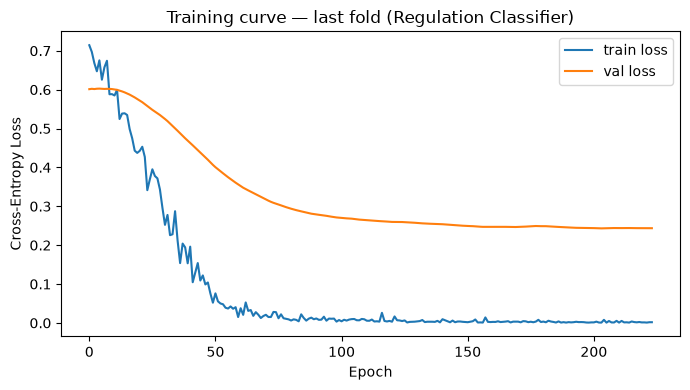

=== Evaluation Dashboard: Regulation (Down / Neither / Up) ===
Model Metrics    -> Accuracy: 0.6400 | Macro F1: 0.5322 | Macro Precision: 0.5317
Baseline Metrics -> Accuracy: 0.7600 (always predicting 'Down (-1)')
⚠️ ALERT: Your Neural Network is currently performing worse than the naive majority-class baseline.



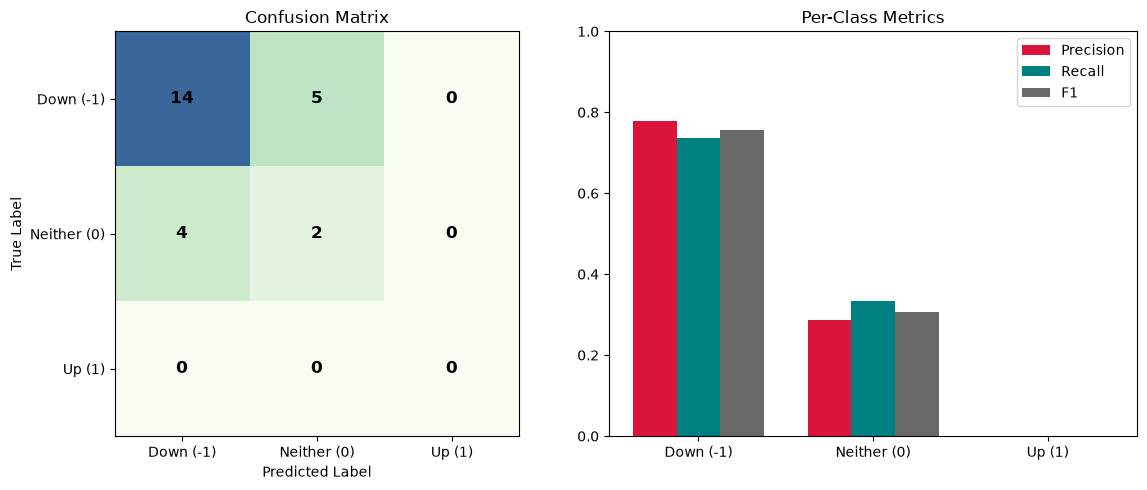

{'accuracy': 0.64,
 'f1_macro': 0.5322245322245323,
 'precision_macro': 0.5317460317460317}

In [24]:
mod = train_model_regulation("PA_shine_data.csv", data_pct=.5, epochs=3000)
test_model_regulation(mod)
# or, on a held-out file:
# test_independent_file_regulation(mod, "some_other_file.csv")